# Chatbot — LangGraph

A simple workflow to understand how LangGraph can be used to build a
basic CHATBOT: a loop where the user sends a message, the LLM
responds, and the full conversation is kept in state.

**What it does:**

- Takes the user's message as INPUT.
- Sends the full conversation so far to the LLM to get a reply.
- Appends both the user's message and the LLM's reply to the
  conversation history.
- Returns the updated conversation as the OUTPUT.

**How it's built:**

- The whole workflow is represented as a **GRAPH** — one node calls
  the LLM using the conversation so far.
- It has a **STATE** — a shared dictionary that holds `messages`,
  a list of `BaseMessage` objects (e.g. `HumanMessage`, `AIMessage`)
  representing the conversation history so far. The `add_messages`
  reducer automatically APPENDS new messages instead of overwriting
  the list.


In [43]:
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages


class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [44]:
from langchain_groq import ChatGroq
from dotenv import load_dotenv

load_dotenv()

model = ChatGroq(model="llama-3.1-8b-instant")

In [45]:
def chat_node(state: ChatState) -> ChatState:
    messages = state["messages"]

    response = model.invoke(messages)

    return {"messages": [response]}

In [46]:
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver

# checkpointer — saves the state after every step so the conversation
# can be persisted/resumed across invocations (per thread_id)
checkpointer = MemorySaver()

# define the graph
graph = StateGraph(ChatState)

# define nodes
graph.add_node("chat_node", chat_node)

# add edges
graph.add_edge(START, "chat_node")
graph.add_edge("chat_node", END)

# compile graph — pass the checkpointer here
workflow = graph.compile(checkpointer=checkpointer)

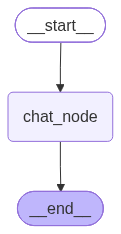

In [47]:
# print/visualize the graph
from IPython.display import Image, display

display(Image(workflow.get_graph().draw_mermaid_png()))

In [48]:
from langchain_core.messages import HumanMessage

# execute the graph — thread_id is required now that a checkpointer is set
config = {"configurable": {"thread_id": "1"}}

initial_state = {"messages": [HumanMessage(content="What is the capital of France?")]}

final_state = workflow.invoke(initial_state, config=config)

for message in final_state["messages"]:
    print(f"{message.type}: {message.content}")

human: What is the capital of France?
ai: The capital of France is Paris.


In [49]:
# interactive chat loop
while True:
    user_message = input("You: ")
    print("You:", user_message)

    if user_message.lower() in ["quit", "bye", "exit"]:
        break

    initial_state = {"messages": [HumanMessage(content=user_message)]}

    final_state = workflow.invoke(initial_state, config=config)

    print("AI:", final_state["messages"][-1].content)

You: hello my name is abc
AI: Hello abc, it's nice to meet you. Is there anything I can help you with or would you like to chat?
You: what is my name
AI: Your name is abc.
You: what are you doing
AI: I'm assisting users by answering their questions and engaging in conversation. I can provide information on a wide range of topics, offer suggestions, and even help with tasks such as language translation or text summarization.
You: what is ur work
AI: My work is to assist and communicate with users like you through text-based conversations. I'm a large language model, which means I'm trained on a massive dataset of text from various sources and can understand and respond to natural language inputs. My main functions include:

1. Answering questions on various topics
2. Providing information and explanations
3. Engaging in conversations
4. Translating text
5. Summarizing long pieces of text
6. Generating text based on prompts or topics

I'm a machine, so I don't have a physical job or loca

In [50]:
# fetch the current persisted state for this thread_id from the checkpointer
workflow.get_state(config)

StateSnapshot(values={'messages': [HumanMessage(content='What is the capital of France?', additional_kwargs={}, response_metadata={}, id='8706a9d6-6271-4d10-a10d-930e4e38b189'), AIMessage(content='The capital of France is Paris.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 8, 'prompt_tokens': 42, 'total_tokens': 50, 'completion_time': 0.006635942, 'completion_tokens_details': None, 'prompt_time': 0.001940105, 'prompt_tokens_details': None, 'queue_time': 0.049892284, 'total_time': 0.008576047}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f9d57-0a4e-7ce3-83be-f82eb5201353-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 42, 'output_tokens': 8, 'total_tokens': 50}), HumanMessage(content='hello my name is abc', additional_kwargs={}, response_metadata={}, id='73494216-d366-474d-9aff-ceb7

StateSnapshot(values={'messages': [HumanMessage(content='What is the capital of France?', additional_kwargs={}, response_metadata={}, id='8706a9d6-6271-4d10-a10d-930e4e38b189'), AIMessage(content='The capital of France is Paris.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 8, 'prompt_tokens': 42, 'total_tokens': 50, 'completion_time': 0.006635942, 'completion_tokens_details': None, 'prompt_time': 0.001940105, 'prompt_tokens_details': None, 'queue_time': 0.049892284, 'total_time': 0.008576047}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f9d57-0a4e-7ce3-83be-f82eb5201353-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 42, 'output_tokens': 8, 'total_tokens': 50}), HumanMessage(content='hello my name is abc', additional_kwargs={}, response_metadata={}, id='73494216-d366-474d-9aff-ceb73f87ac71'), AIMessage(content="Hello abc, it's nice to meet you. Is there anything I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 26, 'prompt_tokens': 64, 'total_tokens': 90, 'completion_time': 0.026354734, 'completion_tokens_details': None, 'prompt_time': 0.004689698, 'prompt_tokens_details': None, 'queue_time': 0.053795801, 'total_time': 0.031044432}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f9d57-1c6c-71e0-ade0-85e5d7d82c79-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 64, 'output_tokens': 26, 'total_tokens': 90}), HumanMessage(content='what is my name', additional_kwargs={}, response_metadata={}, id='4900539c-653e-4196-8c97-f9501f74de94'), AIMessage(content='Your name is abc.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 6, 'prompt_tokens': 103, 'total_tokens': 109, 'completion_time': 0.009826971, 'completion_tokens_details': None, 'prompt_time': 0.007058978, 'prompt_tokens_details': None, 'queue_time': 0.050751462, 'total_time': 0.016885949}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f9d57-29d5-74e2-b71d-07dde0c8fd15-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 103, 'output_tokens': 6, 'total_tokens': 109}), HumanMessage(content='what are you doing', additional_kwargs={}, response_metadata={}, id='a3781ab7-247e-462f-858a-77c225c93198'), AIMessage(content="I'm assisting users by answering their questions and engaging in conversation. I can provide information on a wide range of topics, offer suggestions, and even help with tasks such as language translation or text summarization.", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 42, 'prompt_tokens': 122, 'total_tokens': 164, 'completion_time': 0.069590005, 'completion_tokens_details': None, 'prompt_time': 0.00765485, 'prompt_tokens_details': None, 'queue_time': 0.05080174, 'total_time': 0.077244855}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f9d57-377b-7ec3-8de8-86fc420cec35-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 122, 'output_tokens': 42, 'total_tokens': 164}), HumanMessage(content='what is ur work', additional_kwargs={}, response_metadata={}, id='15ccc159-e012-44cd-a959-ef5716cf34a5'), AIMessage(content="My work is to assist and communicate with users like you through text-based conversations. I'm a large language model, which means I'm trained on a massive dataset of text from various sources and can understand and respond to natural language inputs. My main functions include:\n\n1. Answering questions on various topics\n2. Providing information and explanations\n3. Engaging in conversations\n4. Translating text\n5. Summarizing long pieces of text\n6. Generating text based on prompts or topics\n\nI'm a machine, so I don't have a physical job or location, but I'm always here and ready to help whenever you need it!", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 133, 'prompt_tokens': 177, 'total_tokens': 310, 'completion_time': 0.179286845, 'completion_tokens_details': None, 'prompt_time': 0.010841302, 'prompt_tokens_details': None, 'queue_time': 0.162938907, 'total_time': 0.190128147}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_7ccc667439', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f9d57-49f3-7dc1-b9e5-9f0194457e89-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 177, 'output_tokens': 133, 'total_tokens': 310}), HumanMessage(content='tell me joke', additional_kwargs={}, response_metadata={}, id='ae57425b-0c9d-48f2-800b-ad066066edf5'), AIMessage(content="Here's one:\n\nWhat do you call a fake noodle?\n\nAn impasta.", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 18, 'prompt_tokens': 322, 'total_tokens': 340, 'completion_time': 0.033867136, 'completion_tokens_details': None, 'prompt_time': 0.02520329, 'prompt_tokens_details': None, 'queue_time': 0.05248838, 'total_time': 0.059070426}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f9d57-59e3-75f2-a46c-d66924f80863-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 322, 'output_tokens': 18, 'total_tokens': 340})]}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f188c43-7c4c-6328-8010-621ccab8c003'}}, metadata={'source': 'loop', 'step': 16, 'parents': {}}, created_at='2026-07-26T07:32:55.580522+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f188c43-7a87-66b4-800f-5ea0be2c4daf'}}, tasks=(), interrupts=())
